In [26]:
# =========================
# Mount Google Drive (Colab only)
# =========================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted at /content/drive")
except ImportError:
    print("Not running in Google Colab. Skipping Drive mount.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted at /content/drive


In [27]:
# =========================
# 1) Install + imports
# =========================
# (In Colab) uncomment if needed:
# !pip -q install torch torchvision pillow matplotlib tqdm

import os, glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import urllib.request

In [28]:
# =========================
# 2) Model definition
# =========================

def center_crop(enc_feat, dec_feat):
    _, _, h1, w1 = enc_feat.size()
    _, _, h2, w2 = dec_feat.size()
    delta_h = h1 - h2
    delta_w = w1 - w2
    top = delta_h // 2
    left = delta_w // 2
    return enc_feat[:, :, top:top+h2, left:left+w2]

class UNet(nn.Module):

    def __init__(self, n_channels=3, n_classes=1, base_c=32, dropout_p=0.1):
        super(UNet, self).__init__()
        self.enc1 = self.conv_block(n_channels, base_c, dropout_p)
        self.enc2 = self.conv_block(base_c, base_c*2, dropout_p)
        self.enc3 = self.conv_block(base_c*2, base_c*4, dropout_p)
        self.enc4 = self.conv_block(base_c*4, base_c*8, dropout_p)

        self.pool = nn.MaxPool2d(2)

        self.middle = self.conv_block(base_c*8, base_c*16, dropout_p)

        self.up4 = nn.ConvTranspose2d(base_c*16, base_c*8, 2, stride=2)
        self.dec4 = self.conv_block(base_c*16, base_c*8, dropout_p)

        self.up3 = nn.ConvTranspose2d(base_c*8, base_c*4, 2, stride=2)
        self.dec3 = self.conv_block(base_c*8, base_c*4, dropout_p)

        self.up2 = nn.ConvTranspose2d(base_c*4, base_c*2, 2, stride=2)
        self.dec2 = self.conv_block(base_c*4, base_c*2, dropout_p)

        self.up1 = nn.ConvTranspose2d(base_c*2, base_c, 2, stride=2)
        self.dec1 = self.conv_block(base_c*2, base_c, dropout_p)

        self.final = nn.Conv2d(base_c, n_classes, kernel_size=1)

    def conv_block(self, in_c, out_c, dropout_p):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p)
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        m = self.middle(self.pool(e4))

        d4 = self.up4(m)
        e4_cropped = center_crop(e4, d4)
        d4 = self.dec4(torch.cat([d4, e4_cropped], dim=1))

        d3 = self.up3(d4)
        e3_cropped = center_crop(e3, d3)
        d3 = self.dec3(torch.cat([d3, e3_cropped], dim=1))

        d2 = self.up2(d3)
        e2_cropped = center_crop(e2, d2)
        d2 = self.dec2(torch.cat([d2, e2_cropped], dim=1))

        d1 = self.up1(d2)
        e1_cropped = center_crop(e1, d1)
        d1 = self.dec1(torch.cat([d1, e1_cropped], dim=1))

        out = self.final(d1)
        return torch.sigmoid(out)

def load_model(weights_path, device, base_c=32, dropout_p=0.1):
    model = UNet(n_channels=3, n_classes=1, base_c=base_c, dropout_p=dropout_p).to(device)

    ckpt = torch.load(weights_path, map_location=device)

    # handle different saving styles
    if isinstance(ckpt, dict):
        if "state_dict" in ckpt:
            state = ckpt["state_dict"]
        elif "model_state_dict" in ckpt:
            state = ckpt["model_state_dict"]
        else:
            # might already be a raw state_dict-like dict
            state = ckpt
    else:
        state = ckpt

    # handle DataParallel "module." prefix if present
    new_state = {}
    for k, v in state.items():
        new_state[k.replace("module.", "")] = v

    model.load_state_dict(new_state, strict=True)
    model.eval()
    return model

In [37]:
# =========================
# 3) Download model weights
# =========================

WEIGHTS_NAME = "rhizoannotator_v1.pt"
WEIGHTS_PATH = os.path.join("/content", WEIGHTS_NAME)

WEIGHTS_URL = "https://github.com/egubens/RhizoAnnotator/releases/download/V1.0.0/rhizoannotator_v1.pt"

if not os.path.exists(WEIGHTS_PATH):
    print("Downloading model weights...")
    urllib.request.urlretrieve(WEIGHTS_URL, WEIGHTS_PATH)
    print(f"Weights downloaded to: {WEIGHTS_PATH}")
else:
    print("Weights already available.")

Weights already available.


In [30]:

# =========================
# 4) Config (DEFINED BY USER)
# =========================
# Where the user's images are:
IMG_DIR = "/content/drive/MyDrive/Colab/Switchgrass/Sajid"  # e.g. "/content/drive/MyDrive/my_minirhizotron_images"

# Image size your model expects (match training):
IMG_SIZE = (1024, 1152)

# Output folder:
# - None => save masks in same folder as images
# - or specify a folder path
OUTPUT_DIR = None  # e.g. "/content/drive/MyDrive/masks_out"

# Inference behavior:
BATCH_SIZE = 6              # lower if you hit GPU OOM
THRESHOLD = 0.4
NUM_PREVIEW = 10            # preview N predictions (user-adjustable)
SAVE_FORMAT = "PNG"         # PNG recommended
ROOTS_BLACK_BG_WHITE = True # fixes your inversion issue by default

In [31]:
# =========================
# 4) Helpers
# =========================
def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def list_images(img_dir):
    exts = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")
    paths = sorted([p for p in glob.glob(os.path.join(img_dir, "*")) if p.lower().endswith(exts)])
    if len(paths) == 0:
        raise FileNotFoundError(f"No images found in: {img_dir}")
    return paths

def build_transform(img_size):
    return transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor()
    ])

def load_model(weights_path, device):
    model = UNet().to(device)
    state = torch.load(weights_path, map_location=device)
    model.load_state_dict(state)
    model.eval()
    return model

def ensure_out_dir(img_dir, out_dir):
    if out_dir is None:
        return img_dir
    os.makedirs(out_dir, exist_ok=True)
    return out_dir

def tensor_to_mask_image(pred_bin, roots_black_bg_white=True):
    """
    pred_bin: (H,W) torch tensor with values {0,1} where 1 = predicted root
    Output: PIL image mode 'L' with background white (255), roots black (0) by default.
    """
    pred_bin = pred_bin.detach().cpu().float()
    if roots_black_bg_white:
        # root=1 -> black(0), background=0 -> white(255)
        arr = (1.0 - pred_bin) * 255.0
    else:
        # root=1 -> white(255), background=0 -> black(0)
        arr = pred_bin * 255.0
    return Image.fromarray(arr.numpy().astype("uint8"), mode="L")

def save_mask(mask_pil, img_path, out_dir, suffix="-mask", fmt="PNG"):
    base = os.path.splitext(os.path.basename(img_path))[0]
    out_path = os.path.join(out_dir, f"{base}{suffix}.png")  # force .png for masks
    mask_pil.save(out_path, format=fmt)
    return out_path

def preview_results(pairs, max_n=10):
    """
    pairs: list of (original_pil, mask_pil, img_path)
    """
    n = min(max_n, len(pairs))
    if n <= 0:
        return

    plt.figure(figsize=(10, 3*n))
    for i in range(n):
        orig, mask, p = pairs[i]

        plt.subplot(n, 2, 2*i + 1)
        plt.imshow(orig)
        plt.title(f"Original: {os.path.basename(p)}")
        plt.axis("off")

        plt.subplot(n, 2, 2*i + 2)
        plt.imshow(mask, cmap="gray")
        plt.title("Pred mask (roots black, bg white)")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


Device: cuda


Annotating:   0%|          | 0/2 [00:00<?, ?it/s]/tmp/ipykernel_986/3527912764.py:45: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr.numpy().astype("uint8"), mode="L")
Annotating: 100%|██████████| 2/2 [00:03<00:00,  1.65s/it]



Done. Saved 10 masks to:
/content/drive/MyDrive/Colab/Switchgrass/Sajid


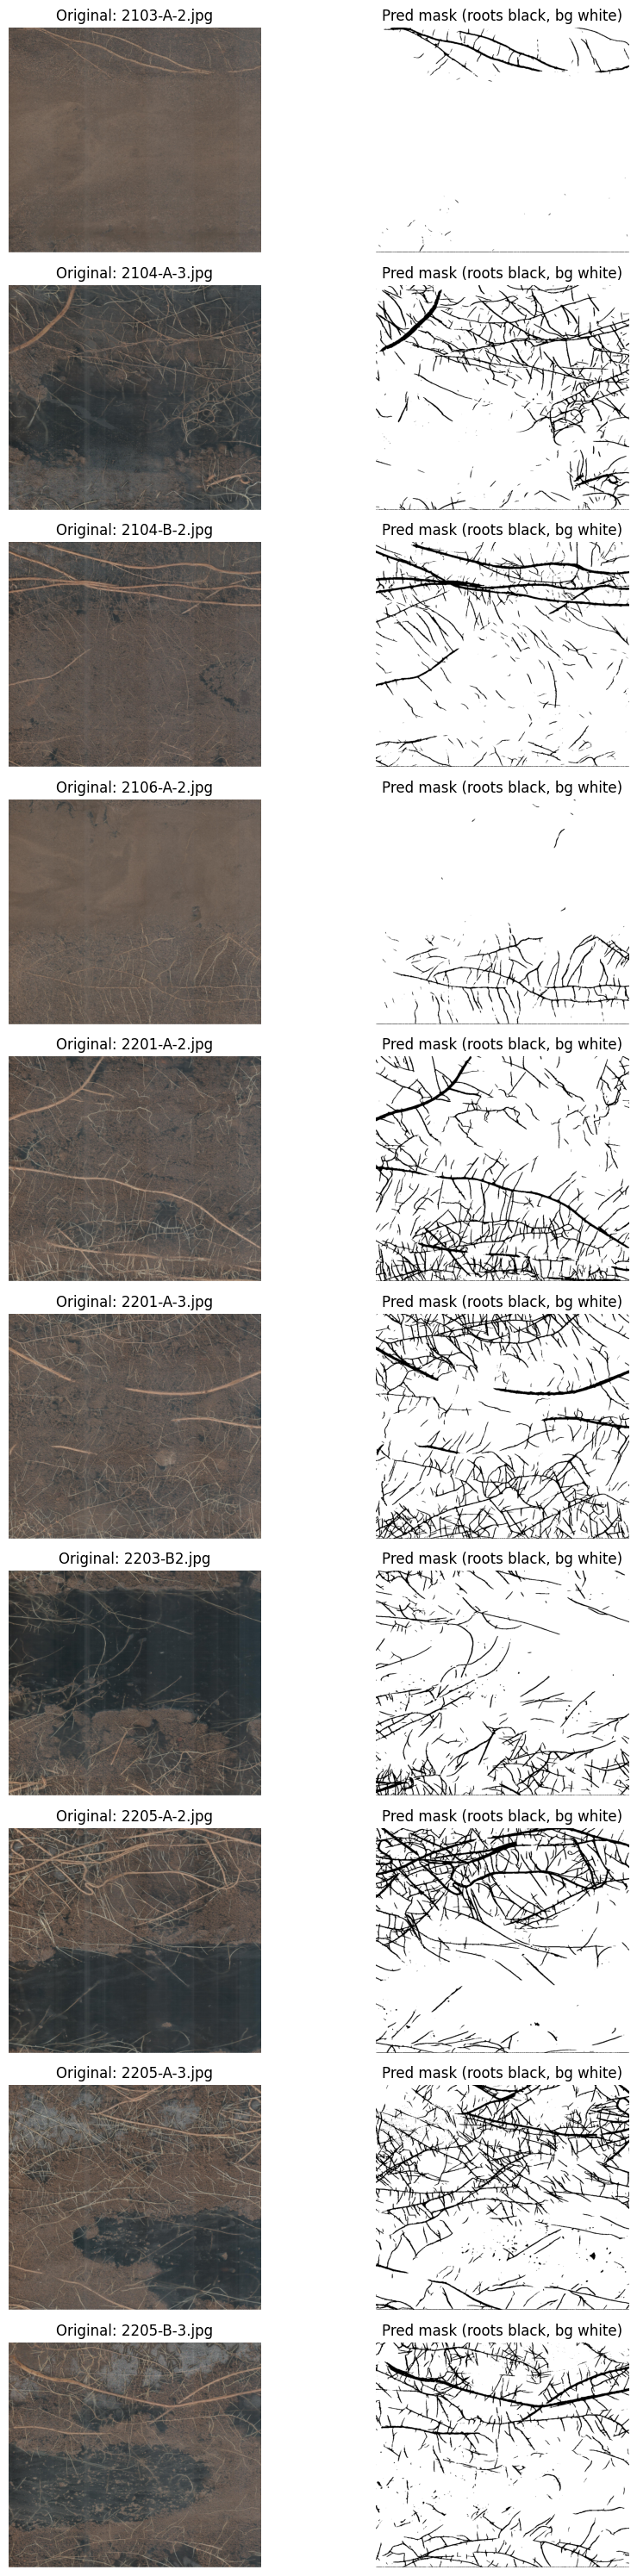

In [38]:

# =========================
# 5) Run inference (batching)
# =========================
device = get_device()
print("Device:", device)

img_paths = list_images(IMG_DIR)
out_dir = ensure_out_dir(IMG_DIR, OUTPUT_DIR)
transform = build_transform(IMG_SIZE)
model = load_model(WEIGHTS_PATH, device)

preview_pairs = []
saved_paths = []

# Batch loop
for start in tqdm(range(0, len(img_paths), BATCH_SIZE), desc="Annotating"):
    batch_paths = img_paths[start:start+BATCH_SIZE]
    originals = []
    batch_tensors = []

    for p in batch_paths:
        im = Image.open(p).convert("RGB")
        originals.append(im)
        batch_tensors.append(transform(im))

    x = torch.stack(batch_tensors).to(device)

    with torch.no_grad():
        preds = model(x)  # (B,1,H,W)
        preds_bin = (preds > THRESHOLD).float().squeeze(1)  # (B,H,W)

    for i, p in enumerate(batch_paths):
        mask_pil = tensor_to_mask_image(preds_bin[i], roots_black_bg_white=ROOTS_BLACK_BG_WHITE)
        out_path = save_mask(mask_pil, p, out_dir, suffix="-mask", fmt=SAVE_FORMAT)
        saved_paths.append(out_path)

        # store preview
        if len(preview_pairs) < NUM_PREVIEW:
            preview_pairs.append((originals[i], mask_pil, p))

print(f"\nDone. Saved {len(saved_paths)} masks to:\n{out_dir}")

# Show preview (user-adjustable NUM_PREVIEW)
preview_results(preview_pairs, max_n=NUM_PREVIEW)